###### 132_5_practical_lcm_weekly_category_pivot.ipynb

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
plt.rcParams["font.family"] = "Meiryo"
plt.rcParams["axes.unicode_minus"] = False

In [3]:
df = pd.read_csv(
    "dataset/lcm_weekly_defect_practice.csv",
    encoding="utf-8-sig",
)
df

,defect_id,site,model,defect_category,defect_qty,inspection_qty,occ_at_jst,status
0,D001,SUS,J69P,Buck-IC,3,30000.0,2026-06-29 08:30:00+09:00,回答済
1,D002,WSE,310D,Coil,1,28000.0,2026-06-30 13:20:00+09:00,回答済
2,D003,GSE,36WA,NTF,1,24000.0,2026-07-01 09:10:00+09:00,調査中
3,D004,META,J69P,Buck-IC,2,52000.0,2026-07-03 21:45:00+09:00,回答済
4,D005,MEAX,310D,Coil,4,18000.0,2026-07-05 11:05:00+09:00,回答済
5,D006,MELAC,3BVT,NTF,1,16000.0,2026-07-06 07:40:00+09:00,回答済
6,D007,SUS,36WA,Buck-IC,5,31000.0,2026-07-07 17:20:00+09:00,調査中
7,D008,WSE,J69P,Coil,2,30000.0,2026-07-08 19:30:00+09:00,回答済
8,D009,GSE,310D,Coil,3,22000.0,2026-07-10 10:15:00+09:00,回答済
9,D010,META,36WA,Buck-IC,2,50000.0,2026-07-12 23:55:00+09:00,回答済


In [4]:
df.head(1)

,defect_id,site,model,defect_category,defect_qty,inspection_qty,occ_at_jst,status
0,D001,SUS,J69P,Buck-IC,3,30000.0,2026-06-29 08:30:00+09:00,回答済


In [5]:
df["defect_qty_num"] = pd.to_numeric(
    df["defect_qty"],
    errors="coerce",
)
df[
    [
        "defect_qty",
        "defect_qty_num",
    ]
].head()

,defect_qty,defect_qty_num
0,3,3.0
1,1,1.0
2,1,1.0
3,2,2.0
4,4,4.0


In [6]:
df["inspection_qty_num"] = pd.to_numeric(
    df["inspection_qty"],
    errors="coerce",
)

df[
    [
        "inspection_qty",
        "inspection_qty_num",
    ]
].head()

,inspection_qty,inspection_qty_num
0,30000.0,30000.0
1,28000.0,28000.0
2,24000.0,24000.0
3,52000.0,52000.0
4,18000.0,18000.0


In [7]:
df["occ_at_jst_raw"] = df["occ_at_jst"]

In [8]:
df["occ_at_jst_raw"].head()

0    2026-06-29 08:30:00+09:00
1    2026-06-30 13:20:00+09:00
2    2026-07-01 09:10:00+09:00
3    2026-07-03 21:45:00+09:00
4    2026-07-05 11:05:00+09:00
Name: occ_at_jst_raw, dtype: object

In [9]:
df["occ_at_jst_clean"] = (
    df["occ_at_jst"]
    .astype("string")
    .str.strip()
)

df[
    [
        "occ_at_jst",
        "occ_at_jst_clean",
    ]
].head()

,occ_at_jst,occ_at_jst_clean
0,2026-06-29 08:30:00+09:00,2026-06-29 08:30:00+09:00
1,2026-06-30 13:20:00+09:00,2026-06-30 13:20:00+09:00
2,2026-07-01 09:10:00+09:00,2026-07-01 09:10:00+09:00
3,2026-07-03 21:45:00+09:00,2026-07-03 21:45:00+09:00
4,2026-07-05 11:05:00+09:00,2026-07-05 11:05:00+09:00


In [10]:
df["occ_at_jst_dt"] = pd.to_datetime(
    df["occ_at_jst_clean"],
    errors="coerce",
)

df[
    [
        "occ_at_jst_dt",
        "occ_at_jst_clean",
    ]
]

,occ_at_jst_dt,occ_at_jst_clean
0,2026-06-29 08:30:00+09:00,2026-06-29 08:30:00+09:00
1,2026-06-30 13:20:00+09:00,2026-06-30 13:20:00+09:00
2,2026-07-01 09:10:00+09:00,2026-07-01 09:10:00+09:00
3,2026-07-03 21:45:00+09:00,2026-07-03 21:45:00+09:00
4,2026-07-05 11:05:00+09:00,2026-07-05 11:05:00+09:00
5,2026-07-06 07:40:00+09:00,2026-07-06 07:40:00+09:00
6,2026-07-07 17:20:00+09:00,2026-07-07 17:20:00+09:00
7,2026-07-08 19:30:00+09:00,2026-07-08 19:30:00+09:00
8,2026-07-10 10:15:00+09:00,2026-07-10 10:15:00+09:00
9,2026-07-12 23:55:00+09:00,2026-07-12 23:55:00+09:00


In [11]:
df_work = df[
    df["occ_at_jst_dt"].notna()
    & df["defect_qty_num"].notna()
    & df["inspection_qty_num"].notna()
].copy()

df_work.head()

,defect_id,site,model,defect_category,defect_qty,inspection_qty,occ_at_jst,status,defect_qty_num,inspection_qty_num,occ_at_jst_raw,occ_at_jst_clean,occ_at_jst_dt
0,D001,SUS,J69P,Buck-IC,3,30000.0,2026-06-29 08:30:00+09:00,回答済,3.0,30000.0,2026-06-29 08:30:00+09:00,2026-06-29 08:30:00+09:00,2026-06-29 08:30:00+09:00
1,D002,WSE,310D,Coil,1,28000.0,2026-06-30 13:20:00+09:00,回答済,1.0,28000.0,2026-06-30 13:20:00+09:00,2026-06-30 13:20:00+09:00,2026-06-30 13:20:00+09:00
2,D003,GSE,36WA,NTF,1,24000.0,2026-07-01 09:10:00+09:00,調査中,1.0,24000.0,2026-07-01 09:10:00+09:00,2026-07-01 09:10:00+09:00,2026-07-01 09:10:00+09:00
3,D004,META,J69P,Buck-IC,2,52000.0,2026-07-03 21:45:00+09:00,回答済,2.0,52000.0,2026-07-03 21:45:00+09:00,2026-07-03 21:45:00+09:00,2026-07-03 21:45:00+09:00
4,D005,MEAX,310D,Coil,4,18000.0,2026-07-05 11:05:00+09:00,回答済,4.0,18000.0,2026-07-05 11:05:00+09:00,2026-07-05 11:05:00+09:00,2026-07-05 11:05:00+09:00


In [12]:
iso_df = df_work["occ_at_jst_dt"].dt.isocalendar()
iso_df

df_work["week_group"] = (
    iso_df["year"] * 100
    + iso_df["week"]
).astype(int)

df_work.head()

,defect_id,site,model,defect_category,defect_qty,inspection_qty,occ_at_jst,status,defect_qty_num,inspection_qty_num,occ_at_jst_raw,occ_at_jst_clean,occ_at_jst_dt,week_group
0,D001,SUS,J69P,Buck-IC,3,30000.0,2026-06-29 08:30:00+09:00,回答済,3.0,30000.0,2026-06-29 08:30:00+09:00,2026-06-29 08:30:00+09:00,2026-06-29 08:30:00+09:00,202627
1,D002,WSE,310D,Coil,1,28000.0,2026-06-30 13:20:00+09:00,回答済,1.0,28000.0,2026-06-30 13:20:00+09:00,2026-06-30 13:20:00+09:00,2026-06-30 13:20:00+09:00,202627
2,D003,GSE,36WA,NTF,1,24000.0,2026-07-01 09:10:00+09:00,調査中,1.0,24000.0,2026-07-01 09:10:00+09:00,2026-07-01 09:10:00+09:00,2026-07-01 09:10:00+09:00,202627
3,D004,META,J69P,Buck-IC,2,52000.0,2026-07-03 21:45:00+09:00,回答済,2.0,52000.0,2026-07-03 21:45:00+09:00,2026-07-03 21:45:00+09:00,2026-07-03 21:45:00+09:00,202627
4,D005,MEAX,310D,Coil,4,18000.0,2026-07-05 11:05:00+09:00,回答済,4.0,18000.0,2026-07-05 11:05:00+09:00,2026-07-05 11:05:00+09:00,2026-07-05 11:05:00+09:00,202627


In [13]:
df_week_category_summary = df_work.groupby(
    [
        "week_group",
        "defect_category",
    ],
    as_index=False,
).agg(
    defect_count=("defect_id", "count"),
    defect_qty_sum=("defect_qty_num", "sum"),
    inspection_qty_sum=("inspection_qty_num", "sum"),
)

df_week_category_summary.head(3)

,week_group,defect_category,defect_count,defect_qty_sum,inspection_qty_sum
0,202627,Buck-IC,2,5.0,82000.0
1,202627,Coil,2,5.0,46000.0
2,202627,NTF,1,1.0,24000.0


In [14]:
df_week_category_summary.head()

,week_group,defect_category,defect_count,defect_qty_sum,inspection_qty_sum
0,202627,Buck-IC,2,5.0,82000.0
1,202627,Coil,2,5.0,46000.0
2,202627,NTF,1,1.0,24000.0
3,202628,Buck-IC,2,7.0,81000.0
4,202628,Coil,2,5.0,52000.0


In [15]:
df_week_category_summary["ppm"] = (
    df_week_category_summary["defect_qty_sum"]
    / df_week_category_summary["inspection_qty_sum"]
    * 1000000
).round(1)
df_week_category_summary["ppm"].head(3)

0     61.0
1    108.7
2     41.7
Name: ppm, dtype: float64

In [16]:
df_week_category_summary.head(3)

,week_group,defect_category,defect_count,defect_qty_sum,inspection_qty_sum,ppm
0,202627,Buck-IC,2,5.0,82000.0,61.0
1,202627,Coil,2,5.0,46000.0,108.7
2,202627,NTF,1,1.0,24000.0,41.7


In [19]:
df_week_category_summary["defect_qty_sum"] = (
    df_week_category_summary["defect_qty_sum"].astype(int)
)
df_week_category_summary["inspection_qty_sum"] = (
    df_week_category_summary["inspection_qty_sum"].astype(int)
)
df_week_category_summary.dtypes

week_group              int64
defect_category        object
defect_count            int64
defect_qty_sum          int64
inspection_qty_sum      int64
ppm                   float64
dtype: object

In [25]:
df_week_category_pivot = df_week_category_summary.pivot_table(
    index="week_group",
    columns="defect_category",
    values="defect_qty_sum",
    fill_value=0,
).reset_index()

df_week_category_pivot.columns.name = None
df_week_category_pivot

,week_group,Buck-IC,Coil,NTF
0,202627,5.0,5.0,1.0
1,202628,7.0,5.0,1.0
2,202629,4.0,4.0,2.0
3,202630,5.0,6.0,1.0
4,202631,5.0,1.0,1.0
5,202632,4.0,4.0,1.0
6,202633,0.0,1.0,0.0


In [28]:
category_cols = [
    "Buck-IC",
    "Coil",
    "NTF",
]

df_week_category_pivot = df_week_category_pivot[
    [
        "week_group",
    ]
    + category_cols
]

df_week_category_pivot[category_cols] = (
    df_week_category_pivot[category_cols].astype(int)
)
df_week_category_pivot

,week_group,Buck-IC,Coil,NTF
0,202627,5,5,1
1,202628,7,5,1
2,202629,4,4,2
3,202630,5,6,1
4,202631,5,1,1
5,202632,4,4,1
6,202633,0,1,0


In [29]:
plt.figure(figsize=(10, 4))

<Figure size 1000x400 with 0 Axes>

<Figure size 1000x400 with 0 Axes>

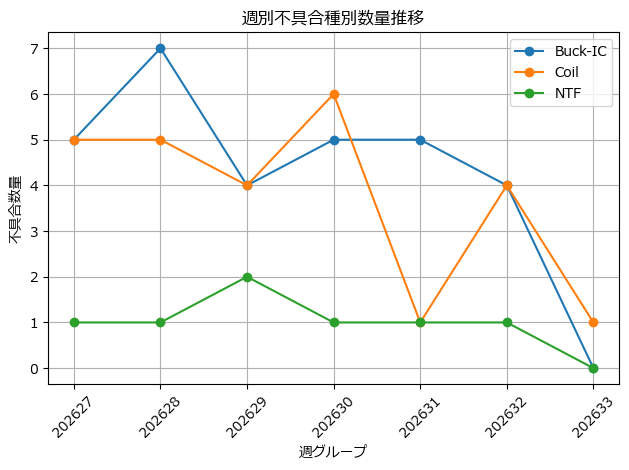

In [39]:
for category in category_cols:
    plt.plot(
        df_week_category_pivot["week_group"].astype(str),
        df_week_category_pivot[category],
        marker="o",
        label=category,
    )

plt.title("週別不具合種別数量推移")
plt.xlabel("週グループ")
plt.ylabel("不具合数量")
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()